In [83]:
import numpy as np 
import matplotlib.pyplot as plt
import OrcFxAPI

In [84]:
# Pad naar je OrcaFlex modelbestand
model_path1 = r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Harlequin_spring_120s.dat"
model_path2 = r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Harlequin_spring_120s_addedmass.dat"


model_path1 = r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Harlequin_fixed_120s.dat"
model_path2 = r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Harlequin_fixed_120s_addedmass.dat"


exp_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\002\34224_03CB_02_002_007_01_Decay1.h5m"

model1 = OrcFxAPI.Model(model_path1)
constraint1 = model1["decay_constraint"]
floaters1 = model1["floaters"]
floatertype1 = model1["Floatertype"]

model2 = OrcFxAPI.Model(model_path2)
constraint2 = model2["decay_constraint"]
floaters2 = model2["floaters"]
floatertype2 = model2["Floatertype"]
buoy2 = model2["6D buoy1"]

In [85]:
floaters1.InitialX = 0.0
floaters1.InitialY = 0.0
floaters1.InitialZ = 0
floaters1.InitialHeel = 0.0
floaters1.InitialTrim = 6.0
floaters1.InitialHeading = 0.0

floaters2.InitialX = 0.0
floaters2.InitialY = 0.0
floaters2.InitialZ = 0
floaters2.InitialHeel = 0.0
floaters2.InitialTrim = 6.0
floaters2.InitialHeading = 0.0

In [86]:
floatertype1.OtherDampingLinearCoeffx = 0 #surge
floatertype1.OtherDampingLinearCoeffy = 0 #sway
floatertype1.OtherDampingLinearCoeffz  = 0 #heav
floatertype1.OtherDampingLinearCoeffRx = 0 #roll
floatertype1.OtherDampingLinearCoeffRy = 0 #pitch
floatertype1.OtherDampingLinearCoeffRz = 0 #yaw

floatertype1.OtherDampingQuadraticCoeffx = 0 #surge
floatertype1.OtherDampingQuadraticCoeffy = 0 #sway 
floatertype1.OtherDampingQuadraticCoeffz = 0 #heav
floatertype1.OtherDampingQuadraticCoeffRx = 0#roll
floatertype1.OtherDampingQuadraticCoeffRy = 0 #pitch
floatertype1.OtherDampingQuadraticCoeffRz = 0 #yaw

floatertype2.OtherDampingLinearCoeffx = 0 #surge
floatertype2.OtherDampingLinearCoeffy = 0 #sway
floatertype2.OtherDampingLinearCoeffz  = 0 #heav
floatertype2.OtherDampingLinearCoeffRx = 0 #roll
floatertype2.OtherDampingLinearCoeffRy = 0 #pitch
floatertype2.OtherDampingLinearCoeffRz = 0 #yaw

floatertype2.OtherDampingQuadraticCoeffx = 0 #surge
floatertype2.OtherDampingQuadraticCoeffy = 0 #sway 
floatertype2.OtherDampingQuadraticCoeffz = 0 #heav
floatertype2.OtherDampingQuadraticCoeffRx = 0#roll
floatertype2.OtherDampingQuadraticCoeffRy = 0 #pitch
floatertype2.OtherDampingQuadraticCoeffRz = 0 #yaw

In [87]:
model1.RunSimulation()
model2.RunSimulation()




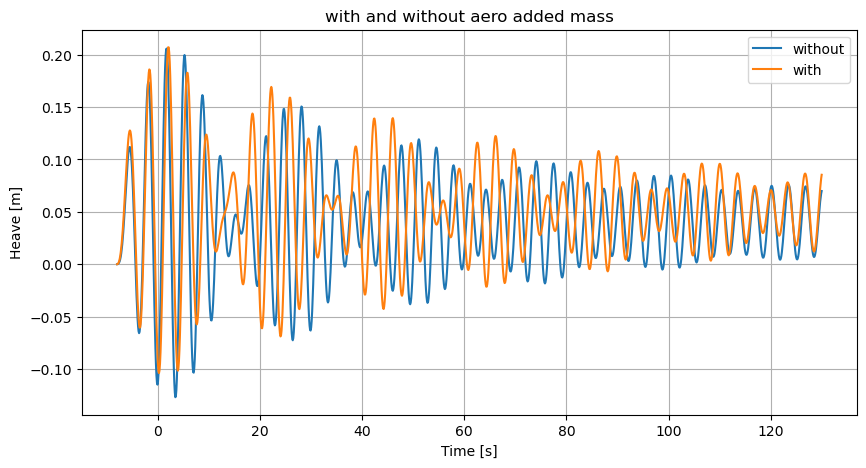

In [88]:
time1 = model1.general.TimeHistory("Time")
heave1 = floaters1.TimeHistory("Z")
roll1 = floaters1.TimeHistory("Rotation 1")
pitch2 = floaters1.TimeHistory("Rotation 2")

time2 = model2.general.TimeHistory("Time")
heave2 = floaters2.TimeHistory("Z")
roll2 = floaters2.TimeHistory("Rotation 1")
pitch2 = floaters2.TimeHistory("Rotation 2")



plt.figure(figsize=(10, 5))
plt.plot(time1, heave1, label="without")
plt.plot(time1, heave2, label="with")


plt.xlabel("Time [s]")
plt.ylabel("Heave [m]")
plt.title("with and without aero added mass")
plt.grid(True)
plt.legend()
plt.show()

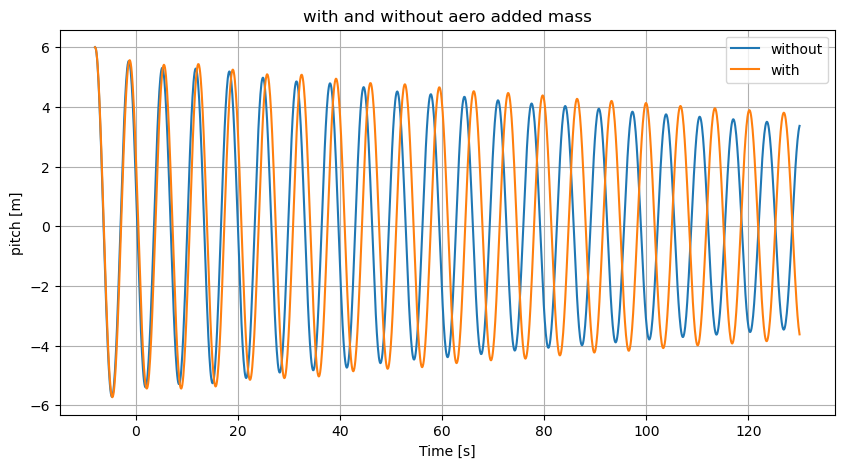

In [89]:
time1 = model1.general.TimeHistory("Time")
heave1 = floaters1.TimeHistory("Z")
roll1 = floaters1.TimeHistory("Rotation 1")
pitch1 = floaters1.TimeHistory("Rotation 2")

time2 = model2.general.TimeHistory("Time")
heave2 = floaters2.TimeHistory("Z")
roll2 = floaters2.TimeHistory("Rotation 1")
pitch2 = floaters2.TimeHistory("Rotation 2")



plt.figure(figsize=(10, 5))
plt.plot(time1, pitch1, label="without")
plt.plot(time2, pitch2, label="with")

# plt.xlim(-10,20)

plt.xlabel("Time [s]")
plt.ylabel("pitch [m]")
plt.title("with and without aero added mass")
plt.grid(True)
plt.legend()
plt.show()

In [90]:
import numpy as np
from scipy.signal import find_peaks

def calculate_period(time, signal):
    # Vind pieken
    peaks, _ = find_peaks(signal)
    
    # Check of er genoeg pieken zijn
    if len(peaks) < 2:
        return None
    
    # Bereken tijd tussen opeenvolgende pieken
    peak_times = time[peaks]
    periods = np.diff(peak_times)
    
    # Gemiddelde periode
    return np.mean(periods)

In [91]:
T1 = calculate_period(time1, pitch1)
T2 = calculate_period(time2, pitch2)

print("\n--- Resultaten periodes ---")

if T1 is not None:
    print(f"Periode simulatie 1: {T1:.3f} s")
else:
    print("Periode simulatie 1: niet te bepalen")

if T2 is not None:
    print(f"Periode simulatie 2: {T2:.3f} s")
else:
    print("Periode simulatie 2: niet te bepalen")


--- Resultaten periodes ---
Periode simulatie 1: 6.579 s
Periode simulatie 2: 6.742 s
